# LAB2 - Series de tiempo EUR/USD

En este notebook se trabaja el dataset histórico EUR/USD con periodicidad horaria para:
1. Leer datos desde GitHub.
2. Definir la columna `time` como índice.
3. Obtener información general del DataFrame.
4. Revisar nulos y NaN.
5. Usar notación PascalCase y quedarnos con `Close`.
6. Crear `DiffPrice`, histograma y mejor distribución con `fitter`.
7. Filtrar solo datos de 2023.
8. Calcular promedios por 15 días, 1 semana y 1 mes.
9. Construir histogramas por cada mes de 2023.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [48]:
# 1) Leer el dataset desde GitHub
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
df = pd.read_csv(url)

print('Dimensiones iniciales:', df.shape)
df.head()

Dimensiones iniciales: (5000, 13)


,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [49]:
# 2) Definir como índice la columna time
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time').sort_index()

df.head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [50]:
# 3) Información general del DataFrame
print('Info del DataFrame:')
df.info()

print('\nDescripción estadística (columnas numéricas):')
df.describe().T

Info del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB

Descripción estadística (columnas numéricas):


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5000.0,2499.500000,1443.520003,0.000000,1249.750000,2499.500000,3749.250000,4999.00000
open,5000.0,1.043891,0.041135,0.953910,1.002718,1.055670,1.078940,1.10847
high,5000.0,1.044815,0.040991,0.955930,1.003507,1.056795,1.079582,1.10953
low,5000.0,1.042991,0.041263,0.953570,1.001715,1.054960,1.078222,1.10805
close,5000.0,1.043906,0.041135,0.953910,1.002705,1.055700,1.078947,1.10850
tick_volume,5000.0,3690.249400,2800.488505,85.000000,1738.750000,2999.500000,4861.000000,23708.00000
spread,5000.0,8.981600,5.785115,0.000000,8.000000,8.000000,8.000000,183.00000
real_volume,5000.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
MeanCloseOpen,5000.0,1.043898,0.041129,0.954735,1.002648,1.055712,1.078955,1.10828
Diff_Close,5000.0,0.000012,0.001400,-0.013970,-0.000580,-0.000005,0.000620,0.01734


In [51]:
# 4) Verificar valores null / NaN
null_count = df.isnull().sum()
nan_total = df.isna().sum().sum()

print('Nulos por columna:')
print(null_count[null_count > 0] if (null_count > 0).any() else 'No hay nulos por columna')
print('\nTotal de NaN en todo el DataFrame:', nan_total)

Nulos por columna:
No hay nulos por columna

Total de NaN en todo el DataFrame: 0


In [52]:
# 5) Notación PascalCase y trabajar solo con Close
# Renombramos todas las columnas a PascalCase para mantener consistencia
def to_pascal_case(name: str) -> str:
    parts = str(name).replace('-', '_').split('_')
    parts = [p for p in parts if p]
    return ''.join(p[:1].upper() + p[1:] for p in parts)

df = df.rename(columns={col: to_pascal_case(col) for col in df.columns})

# Dejamos únicamente la columna de cierre
df = df[['Close']].copy()
df.head()

,Close
time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181


In [53]:
# 6) Crear DiffPrice (diferencia entre horas)
df['DiffPrice'] = df['Close'].diff()

# Eliminamos la primera fila NaN generada por diff
df = df.dropna().copy()

print('Columnas actuales:', list(df.columns))
print('Dimensiones actuales:', df.shape)
df.head()

Columnas actuales: ['Close', 'DiffPrice']
Dimensiones actuales: (4999, 2)


,Close,DiffPrice
time,,
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
2022-07-25 18:00:00,1.02099,-0.00082


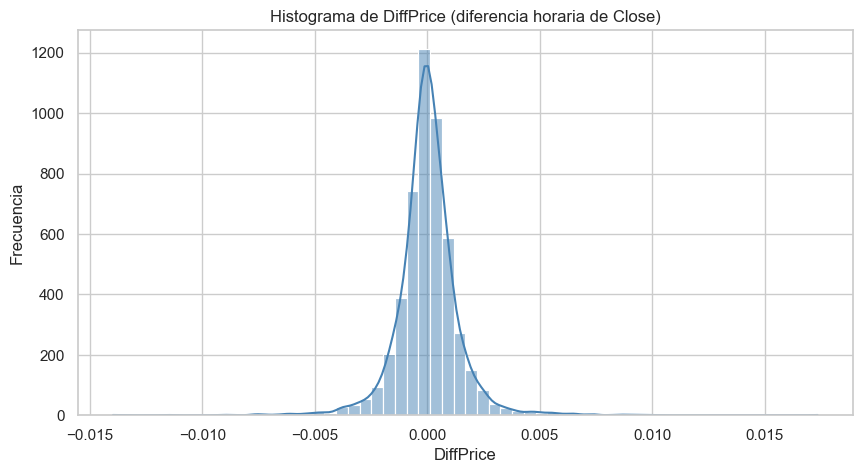

In [54]:
# Histograma de DiffPrice
plt.figure(figsize=(10, 5))
sns.histplot(df['DiffPrice'], bins=60, kde=True, color='steelblue')
plt.title('Histograma de DiffPrice (diferencia horaria de Close)')
plt.xlabel('DiffPrice')
plt.ylabel('Frecuencia')
plt.show()

2026-03-13 11:41:42.159 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=923360.482403, AIC=-17723.24, KS=0.5914
2026-03-13 11:41:42.495 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=106500.661168, AIC=-51509.77, KS=0.0916
2026-03-13 11:41:42.742 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=106676.111621, AIC=-51503.23, KS=0.0908
2026-03-13 11:41:43.630 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted burr: error=721804.561088, AIC=-37765.25, KS=0.3864
2026-03-13 11:41:43.656 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106744.023571, AIC=-51505.72, KS=0.0905


Mejor distribución (SSE): {'lognorm': {'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}}

Total distribuciones disponibles en fitter: 114
Parámetros estimados para beta: (np.float64(14613.527947910232), np.float64(27360.991772190286), np.float64(-0.20964563672636735), np.float64(0.6022017125608812))


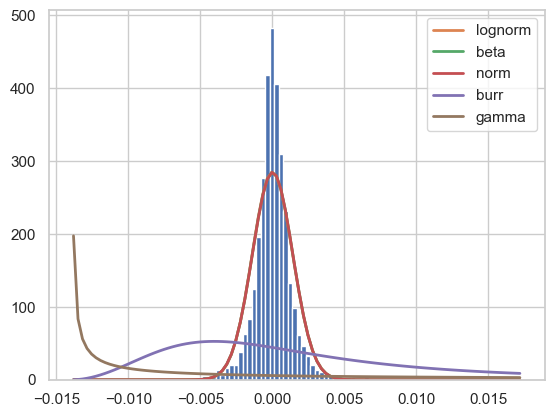

In [55]:
# Ajuste de distribuciones con fitter
from fitter import Fitter, get_distributions

data = df['DiffPrice'].dropna().values
candidate_distributions = ['gamma', 'lognorm', 'beta', 'burr', 'norm']

f = Fitter(data, distributions=candidate_distributions)

# En Windows, usar 1 worker evita errores de serialización al paralelizar
f.fit(max_workers=1)

# Resumen visual del ajuste
f.summary()

# Mejor distribución por error cuadrático
best_dist = f.get_best(method='sumsquare_error')
print('Mejor distribución (SSE):', best_dist)

print('\nTotal distribuciones disponibles en fitter:', len(get_distributions()))

if 'beta' in f.fitted_param:
    print('Parámetros estimados para beta:', f.fitted_param['beta'])
else:
    print('La distribución beta no se pudo ajustar en este caso.')

In [56]:
# 7) Seleccionar solo los datos del año 2023
df_2023 = df.loc['2023'].copy()

print('Rango 2023:', df_2023.index.min(), '->', df_2023.index.max())
print('Dimensiones 2023:', df_2023.shape)
df_2023.head()

Rango 2023: 2023-01-02 00:00:00 -> 2023-05-12 23:00:00
Dimensiones 2023: (2278, 2)


,Close,DiffPrice
time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016


In [57]:
# 8) Promedios por 15 días, 1 semana y 1 mes
mean_15d = df_2023.resample('15D').mean(numeric_only=True)
mean_1w = df_2023.resample('1W').mean(numeric_only=True)
mean_1m = df_2023.resample('1M').mean(numeric_only=True)

print('Promedio cada 15 días:')
display(mean_15d.head())

print('Promedio cada 1 semana:')
display(mean_1w.head())

print('Promedio cada 1 mes:')
display(mean_1m.head())

Promedio cada 15 días:


C:\Users\Asus\AppData\Local\Temp\ipykernel_14940\1587572246.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mean_1m = df_2023.resample('1M').mean(numeric_only=True)


,Close,DiffPrice
time,,
2023-01-02,1.069361,0.000047
2023-01-17,1.085565,0.000015
2023-02-01,1.077679,-0.000066
2023-02-16,1.063150,-0.000034
2023-03-03,1.063186,0.000026


Promedio cada 1 semana:


,Close,DiffPrice
time,,
2023-01-08,1.059972,-0.000047
2023-01-15,1.076002,0.000156
2023-01-22,1.082041,0.000020
2023-01-29,1.088414,0.000010
2023-02-05,1.089281,-0.000062


Promedio cada 1 mes:


,Close,DiffPrice
time,,
2023-01-31,1.077463,0.000031
2023-02-28,1.071167,-0.000060
2023-03-31,1.070874,0.000049
2023-04-30,1.096051,0.000036
2023-05-31,1.098980,-0.000069


C:\Users\Asus\AppData\Local\Temp\ipykernel_14940\2817110720.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_groups = df_2023.groupby(pd.Grouper(freq='M'))


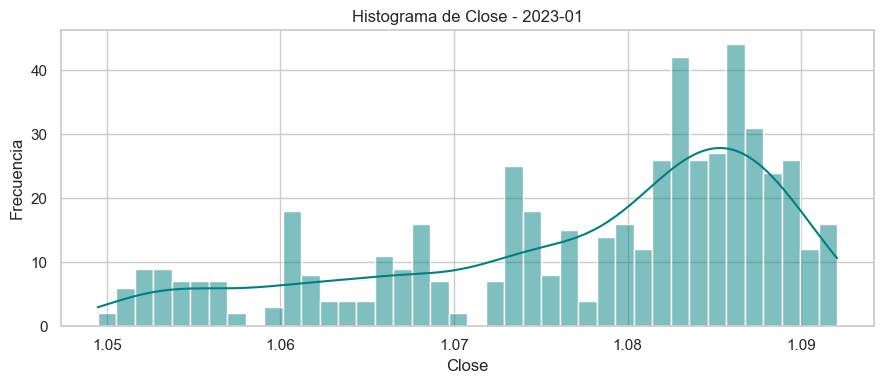

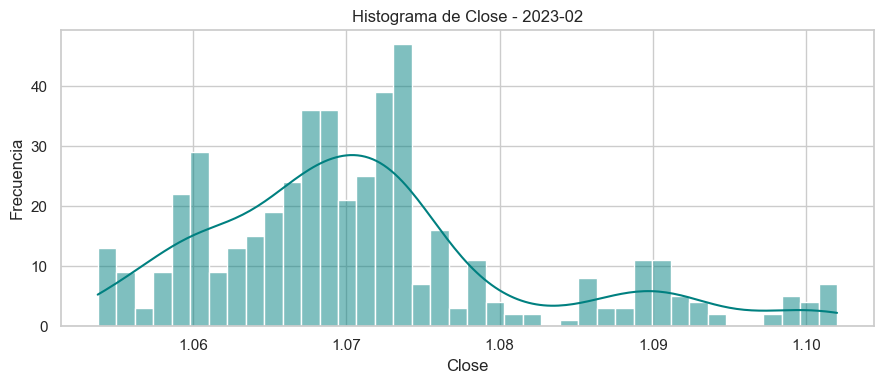

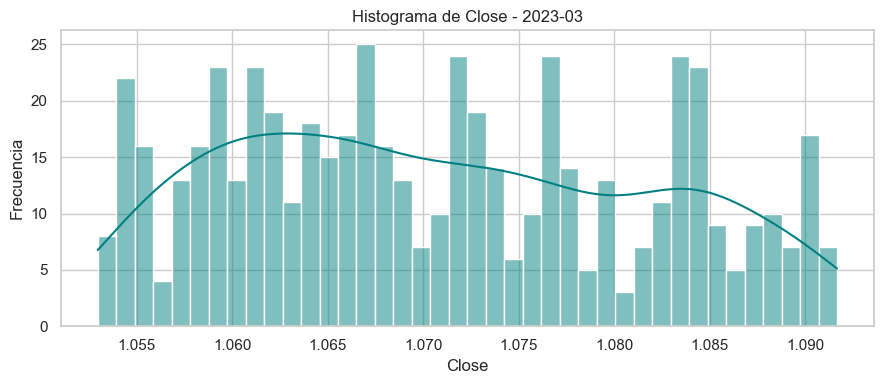

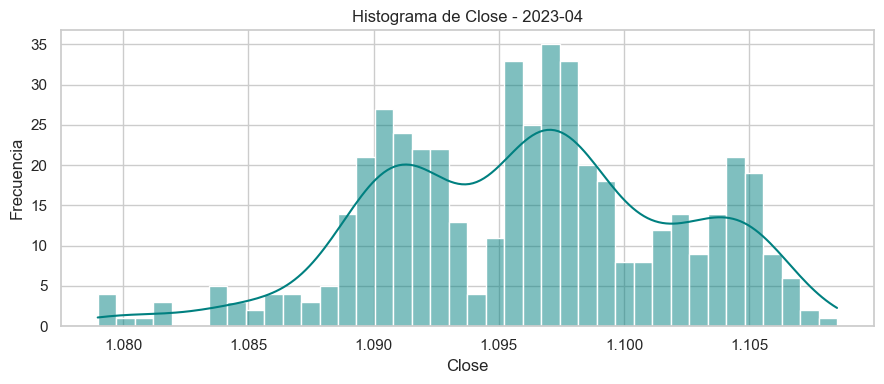

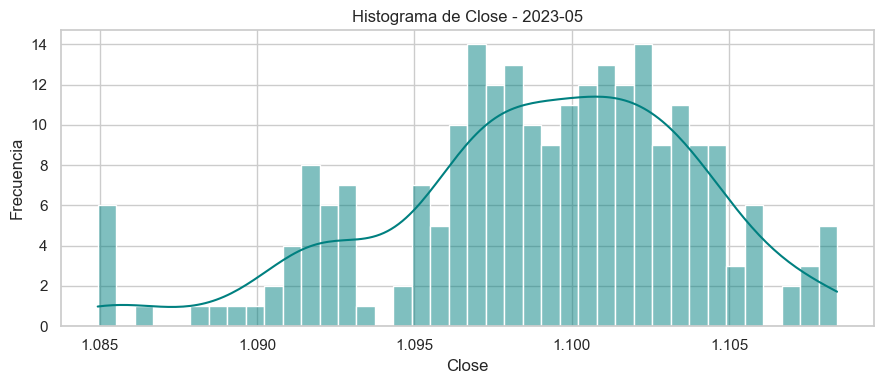

In [58]:
# 9) Histograma de Close para cada mes de 2023
monthly_groups = df_2023.groupby(pd.Grouper(freq='M'))

for month, group in monthly_groups:
    if group.empty:
        continue

    plt.figure(figsize=(9, 4))
    sns.histplot(group['Close'], bins=40, kde=True, color='teal')
    plt.title(f'Histograma de Close - {month:%Y-%m}')
    plt.xlabel('Close')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()